# TS1: Primeros pasos en la simulación.
## Mariano Pittaluga.


### Consigna:
En este primer trabajo comenzaremos por diseñar un generador de señales que utilizaremos en las primeras simulaciones que hagamos. La primer tarea consistirá en programar una función que genere señales senoidales y que permita parametrizar:

    - la amplitud máxima de la senoidal (volts)
    - su valor medio (volts)
    - la frecuencia (Hz)
    - la fase (radianes)
    - la cantidad de muestras digitalizada por el ADC (# muestras)
    - la frecuencia de muestreo del ADC.

es decir que la función que uds armen debería admitir ser llamada de la siguiente manera

tt, xx = mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs)

Recuerden que tanto xx como tt deben ser vectores de Nx1. Puede resultarte útil el módulo de visualización matplotlib.pyplot donde encontrarán todas las funciones de visualización estilo Matlab. Para usarlo:

    import matplotlib.pyplot as plt

    plt.plot(tt, xx)
    
### Bonus:

    💎 Ser el primero en subir un enlace a tu notebook en esta tarea
    🤯 Implementar alguna otra señal propia de un generador de señales. 

### Ayudas:

    - La función numpy.sin seguro te va a servir.
    - No hace falta usar ningún lazo de control for, while, etc.
    - Podés consultar en el chat cualquier duda o problema que vayas encontrando. Buena suerte!



## Resolución: 

In [31]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import signal as sig

# Condiciones de muestreo
N    = 1000 # Muestras
fs   = 1000 # AF = 1


### Función Generador de Señales:

In [32]:
def signal( wave ='sin', vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs, duty=0.5 ):
    
    tt = np.arange(start = 0, step = 1/fs, stop = nn/fs)
    
    match wave:
        case 'sine':
            xx = vmax * np.sin( 2 * np.pi * ff * tt + ph) + dc
        case 'square':
            xx = vmax * sig.square( 2 * np.pi * ff * tt + ph, duty = duty) + dc
        case 'triangle':
            xx = vmax * sig.sawtooth( 2 * np.pi * ff * tt + ph, width=0.5) + dc
        case 'sawtooth':
            xx = vmax * sig.sawtooth( 2 * np.pi * ff * tt + ph) + dc
        case _:
            raise ValueError(f"Tipo '{wave}' no reconocido.")
    
    return tt, xx

## Gráficos: 

### Señal Senoidal:

In [34]:
# Parametros de la Señal
ff   = 5 # Hz
vmax = 1 
dc   = 0
ph   = np.pi

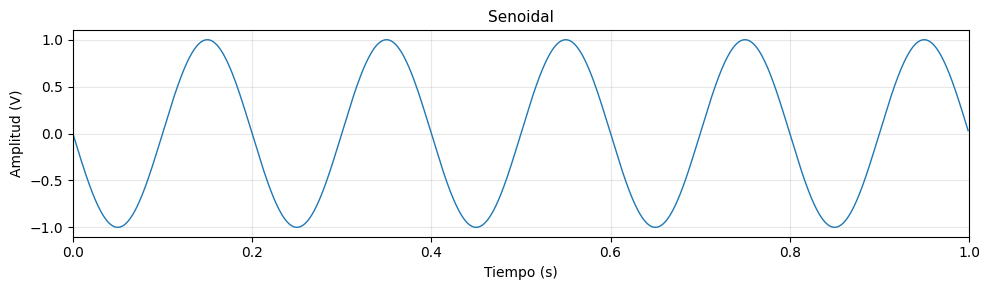

In [35]:
# Visualización
tt, xx = signal(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs, wave='sine')
plt.figure(figsize=(10, 3))
plt.plot(tt, xx, linewidth=1)
plt.title("Senoidal", fontsize=11)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.tight_layout()
plt.show()

### Señal Cuadrada:

In [36]:
# Parametros de la Señal
ff   = 5 # Hz
vmax = 2 
dc   = 1
ph   = 0
duty = 0.75

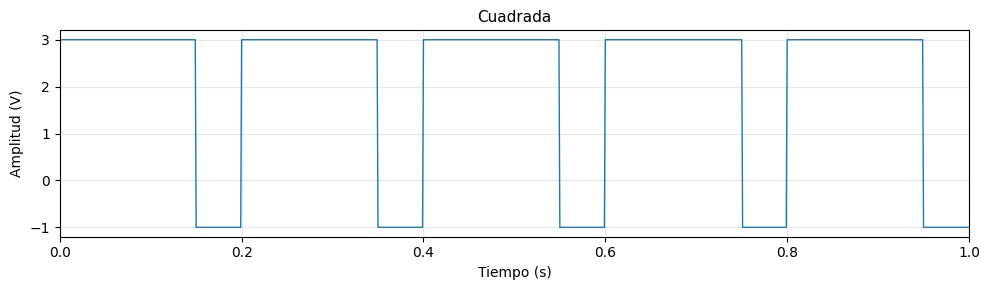

In [37]:
# Visualización
tt, xx = signal(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs, wave='square', duty=duty)
plt.figure(figsize=(10, 3))
plt.plot(tt, xx, linewidth=1)
plt.title("Cuadrada", fontsize=11)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.tight_layout()
plt.show()

### Señal Triangular:

In [38]:
# Parametros de la Señal
ff   = 5 # Hz
vmax = 1 
dc   = 1
ph   = np.pi/2

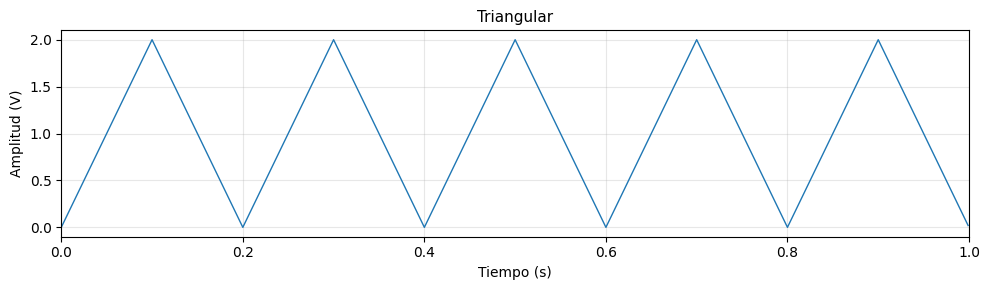

In [39]:
# Visualización
tt, xx = signal(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs, wave='triangle')
plt.figure(figsize=(10, 3))
plt.plot(tt, xx, linewidth=1)
plt.title("Triangular", fontsize=11)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.tight_layout()
plt.show()

### Señal Diente de Sierra:

In [40]:
# Parametros de la Señal
ff   = 10 # Hz
vmax = 5 
dc   = 0
ph   = 0

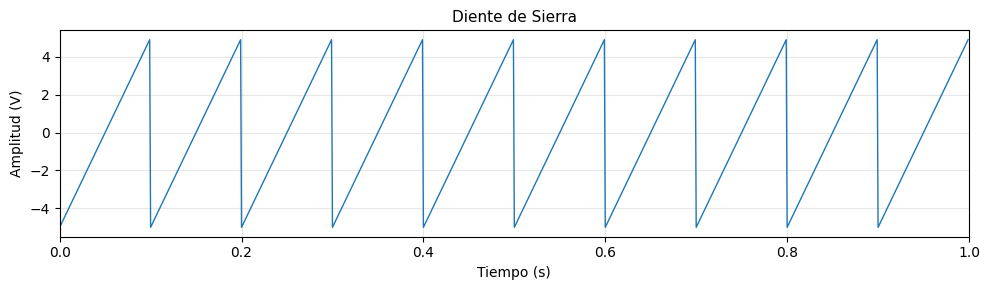

In [41]:
# Visualización
tt, xx = signal(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs, wave='sawtooth')
plt.figure(figsize=(10, 3))
plt.plot(tt, xx, linewidth=1)
plt.title("Diente de Sierra", fontsize=11)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.tight_layout()
plt.show()